# ⚙️ Customer Churn — Preprocessing & Feature Engineering
**Kaggle Playground Series 2026**

Picks up directly from the EDA conclusions. Goal: produce clean, enriched
`X_train`, `y_train`, `X_test` arrays ready for modelling.

### Structure
1. Setup & Load
2. Harmonisation (SeniorCitizen, PaymentMethod)
3. Encoding
4. Feature engineering
5. Final feature matrix
6. Sanity checks
7. Save to disk

---
## 1. Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

DATA_DIR = "/Users/clairedebadts/kaggle/customer-churn/data/"

train_raw = pd.read_csv(DATA_DIR + "train.csv")
test_raw  = pd.read_csv(DATA_DIR + "test.csv")

print(f"Train : {train_raw.shape[0]:,} rows x {train_raw.shape[1]} cols")
print(f"Test  : {test_raw.shape[0]:,} rows x {test_raw.shape[1]} cols")

Train : 594,194 rows x 21 cols
Test  : 254,655 rows x 20 cols


---
## 2. Harmonisation

From EDA:
- `SeniorCitizen` 0/1 → 'No'/'Yes' for consistency during feature engineering
- `PaymentMethod` → `payment_type` (Automatic/Manual) + `payment_method` (actual method)

Applied identically to train and test.

In [2]:
def harmonise(df):
    df = df.copy()

    # SeniorCitizen: 0/1 -> No/Yes
    df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

    # PaymentMethod -> payment_type + payment_method
    df['payment_type'] = df['PaymentMethod'].apply(
        lambda x: 'Automatic' if 'automatic' in x.lower() else 'Manual'
    )
    df['payment_method'] = (
        df['PaymentMethod']
        .str.replace(r'\s*\(automatic\)', '', regex=True)
        .str.strip()
    )

    return df

train = harmonise(train_raw)
test  = harmonise(test_raw)

print("SeniorCitizen :", train['SeniorCitizen'].unique().tolist())
print("payment_type  :", train['payment_type'].unique().tolist())
print("payment_method:", train['payment_method'].unique().tolist())

SeniorCitizen : ['No', 'Yes']
payment_type  : ['Manual', 'Automatic']
payment_method: ['Mailed check', 'Credit card', 'Electronic check', 'Bank transfer']


---
## 3. Encoding

Plan from EDA section 14:

| Column(s) | Strategy | Rationale |
|---|---|---|
| Binary Yes/No cols | 0/1 | No ordering needed |
| `InternetService` | Ordinal 0/1/2 | No < DSL < Fiber (risk gradient) |
| `MultipleLines` | Ordinal 0/1/2 | No phone < No < Yes |
| Internet add-on cols | Ordinal 0/1/2 | No internet < No < Yes (meaningful 3-way) |
| `Contract` | Ordinal 0/1/2 | Month-to-month < One year < Two year |
| `payment_type` | Binary 0/1 | Manual < Automatic |
| `payment_method` | One-hot | 4 categories, no natural order |

In [3]:
TARGET = 'Churn'
ID_COL = 'id'

PROTECTIVE_ADDONS = ['OnlineSecurity', 'TechSupport', 'DeviceProtection', 'OnlineBackup']
STREAMING_ADDONS  = ['StreamingTV', 'StreamingMovies']
INTERNET_ADDON_COLS = PROTECTIVE_ADDONS + STREAMING_ADDONS

def encode(df):
    df = df.copy()

    # ── Binary Yes/No columns → 1/0 ───────────────────────────────────────
    binary_cols = [
        'gender', 'SeniorCitizen', 'Partner', 'Dependents',
        'PhoneService', 'PaperlessBilling', 'payment_type'
    ]
    binary_maps = {
        'gender'          : {'Male': 0, 'Female': 1},
        'SeniorCitizen'   : {'No': 0, 'Yes': 1},
        'Partner'         : {'No': 0, 'Yes': 1},
        'Dependents'      : {'No': 0, 'Yes': 1},
        'PhoneService'    : {'No': 0, 'Yes': 1},
        'PaperlessBilling': {'No': 0, 'Yes': 1},
        'payment_type'    : {'Manual': 0, 'Automatic': 1},
    }
    for col, mapping in binary_maps.items():
        df[col] = df[col].map(mapping)

    # ── InternetService: ordinal ───────────────────────────────────────────
    # No=0 (lowest risk), DSL=1, Fiber optic=2 (highest risk)
    df['InternetService'] = df['InternetService'].map(
        {'No': 0, 'DSL': 1, 'Fiber optic': 2}
    )

    # ── MultipleLines: ordinal ─────────────────────────────────────────────
    # No phone service=0, No=1, Yes=2
    df['MultipleLines'] = df['MultipleLines'].map(
        {'No phone service': 0, 'No': 1, 'Yes': 2}
    )

    # ── Internet add-on cols: ordinal ──────────────────────────────────────
    # No internet service=0 (distinct population), No=1, Yes=2
    addon_map = {'No internet service': 0, 'No': 1, 'Yes': 2}
    for col in INTERNET_ADDON_COLS:
        df[col] = df[col].map(addon_map)

    # ── Contract: ordinal ─────────────────────────────────────────────────
    df['Contract'] = df['Contract'].map(
        {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
    )

    # ── payment_method: one-hot ────────────────────────────────────────────
    df = pd.get_dummies(df, columns=['payment_method'], prefix='pm', drop_first=False)
    # Rename for clarity
    pm_rename = {
        'pm_Bank transfer' : 'pm_bank_transfer',
        'pm_Credit card'   : 'pm_credit_card',
        'pm_Electronic check': 'pm_electronic_check',
        'pm_Mailed check'  : 'pm_mailed_check',
    }
    df = df.rename(columns=pm_rename)

    # Drop original PaymentMethod (replaced by payment_type + one-hot)
    df = df.drop(columns=['PaymentMethod'], errors='ignore')

    return df

train_enc = encode(train)
test_enc  = encode(test)

print("Encoding done.")
print(f"Train cols: {train_enc.shape[1]}  |  Test cols: {test_enc.shape[1]}")
print()
print("Sample encoded row:")
print(train_enc.iloc[0].to_string())

Encoding done.
Train cols: 25  |  Test cols: 24

Sample encoded row:
id                           0
gender                       0
SeniorCitizen                0
Partner                      1
Dependents                   1
tenure                      29
PhoneService                 1
MultipleLines                1
InternetService              1
OnlineSecurity               2
OnlineBackup                 1
DeviceProtection             2
TechSupport                  2
StreamingTV                  1
StreamingMovies              1
Contract                     1
PaperlessBilling             1
MonthlyCharges            60.1
TotalCharges           1653.85
Churn                       No
payment_type                 0
pm_bank_transfer         False
pm_credit_card           False
pm_electronic_check      False
pm_mailed_check           True


In [4]:
# ── Verify: no remaining object columns (except Churn in train) ───────────
obj_train = train_enc.select_dtypes('object').columns.tolist()
obj_test  = test_enc.select_dtypes('object').columns.tolist()

print(f"Object cols remaining in train: {obj_train}")
print(f"Object cols remaining in test : {obj_test}")

# ── Verify: same feature columns in train and test ────────────────────────
train_feat = set(train_enc.columns) - {TARGET}
test_feat  = set(test_enc.columns)
only_train = train_feat - test_feat
only_test  = test_feat - train_feat
print(f"\nOnly in train : {only_train}")
print(f"Only in test  : {only_test}")

Object cols remaining in train: ['Churn']
Object cols remaining in test : []

Only in train : set()
Only in test  : set()


---
## 4. Feature Engineering

All features motivated by EDA findings.

### 4.1 Internet & add-on features

In [5]:
def engineer_internet(df):
    df = df.copy()

    # ── Internet flags ────────────────────────────────────────────────────
    # InternetService is already encoded: 0=No, 1=DSL, 2=Fiber
    df['has_internet'] = (df['InternetService'] > 0).astype(int)
    df['is_fiber']     = (df['InternetService'] == 2).astype(int)

    # ── Protective add-ons (EDA: strong retention anchors) ────────────────
    # Encoded: 0=No internet, 1=No, 2=Yes
    # Count only genuine 'Yes' (=2) subscriptions
    prot_cols_enc = PROTECTIVE_ADDONS  # already encoded in place
    df['num_protective_addons'] = (
        df[prot_cols_enc].apply(lambda col: (col == 2))
    ).sum(axis=1)
    df['has_any_protection'] = (df['num_protective_addons'] > 0).astype(int)

    # Flag: has internet but ZERO protective add-ons (highest risk group)
    df['internet_no_protection'] = (
        (df['has_internet'] == 1) & (df['has_any_protection'] == 0)
    ).astype(int)

    # ── Streaming add-ons (EDA: weak retention, kept separate) ────────────
    df['num_streaming_addons'] = (
        df[STREAMING_ADDONS].apply(lambda col: (col == 2))
    ).sum(axis=1)

    # ── Total add-ons ─────────────────────────────────────────────────────
    df['num_total_addons'] = df['num_protective_addons'] + df['num_streaming_addons']

    return df

train_enc = engineer_internet(train_enc)
test_enc  = engineer_internet(test_enc)

print("Internet & add-on features:")
new_cols = ['has_internet','is_fiber','num_protective_addons',
            'has_any_protection','internet_no_protection',
            'num_streaming_addons','num_total_addons']
print(train_enc[new_cols].describe().round(2).to_string())

Internet & add-on features:
       has_internet   is_fiber  num_protective_addons  has_any_protection  internet_no_protection  num_streaming_addons  num_total_addons
count     594194.00  594194.00              594194.00           594194.00                594194.0             594194.00         594194.00
mean           0.76       0.46                   1.24                0.57                     0.2                  0.81              2.05
std            0.43       0.50                   1.36                0.50                     0.4                  0.89              1.97
min            0.00       0.00                   0.00                0.00                     0.0                  0.00              0.00
25%            1.00       0.00                   0.00                0.00                     0.0                  0.00              0.00
50%            1.00       0.00                   1.00                1.00                     0.0                  0.00              2.00
75%   

### 4.2 Tenure & loyalty features

In [6]:
def engineer_tenure(df):
    df = df.copy()

    # ── Tenure stages — informed by EDA churn rate curve ─────────────────
    df['is_new_customer']  = (df['tenure'] <= 3).astype(int)   # highest churn zone
    df['is_early']         = (df['tenure'] <= 12).astype(int)  # still elevated
    df['is_long_term']     = (df['tenure'] >= 48).astype(int)  # stable zone

    # ── Contract × tenure interaction ─────────────────────────────────────
    # Month-to-month (0) + short tenure = compounded risk
    # Contract is encoded 0/1/2
    df['contract_x_tenure'] = df['Contract'] * df['tenure']

    return df

train_enc = engineer_tenure(train_enc)
test_enc  = engineer_tenure(test_enc)

print("Tenure features:")
tenure_cols = ['is_new_customer','is_early','is_long_term','contract_x_tenure']
print(train_enc[tenure_cols].describe().round(2).to_string())

Tenure features:
       is_new_customer   is_early  is_long_term  contract_x_tenure
count         594194.0  594194.00     594194.00          594194.00
mean               0.1       0.26          0.39              46.40
std                0.3       0.44          0.49              56.57
min                0.0       0.00          0.00               0.00
25%                0.0       0.00          0.00               0.00
50%                0.0       0.00          0.00               0.00
75%                0.0       1.00          1.00             102.00
max                1.0       1.00          1.00             144.00


### 4.3 Charge features — sticker shock

In [7]:
def engineer_charges(df, monthly_q75=None):
    df = df.copy()

    # ── Average monthly charge (corrects for tenure length) ───────────────
    df['avg_monthly_charge'] = df['TotalCharges'] / (df['tenure'] + 1)

    # ── Charge per add-on (value perception) ──────────────────────────────
    df['charge_per_addon'] = df['MonthlyCharges'] / (df['num_total_addons'] + 1)

    # ── Sticker shock flag: new customer with high monthly charges ─────────
    # Threshold computed from TRAIN only, applied to both
    if monthly_q75 is None:
        monthly_q75 = df['MonthlyCharges'].quantile(0.75)
    df['sticker_shock'] = (
        (df['is_new_customer'] == 1) &
        (df['MonthlyCharges'] >= monthly_q75)
    ).astype(int)

    # ── Monthly charges × fiber interaction ───────────────────────────────
    df['charge_x_fiber'] = df['MonthlyCharges'] * df['is_fiber']

    return df, monthly_q75

# Compute threshold from train, reuse for test
train_enc, monthly_q75 = engineer_charges(train_enc)
test_enc, _            = engineer_charges(test_enc, monthly_q75=monthly_q75)

print(f"Monthly charge Q75 (from train): {monthly_q75:.2f}")
print()
charge_cols = ['avg_monthly_charge','charge_per_addon','sticker_shock','charge_x_fiber']
print(train_enc[charge_cols].describe().round(2).to_string())

Monthly charge Q75 (from train): 90.80

       avg_monthly_charge  charge_per_addon  sticker_shock  charge_x_fiber
count           594194.00         594194.00      594194.00       594194.00
mean                61.53             26.32           0.01           42.09
std                 36.75             15.14           0.08           46.63
min                  0.72              4.02           0.00            0.00
25%                 25.47             18.23           0.00            0.00
50%                 64.98             20.65           0.00            0.00
75%                 86.95             28.27           0.00           90.45
max               1046.91             93.70           1.00          118.75


### 4.4 Demographic & lifestyle features

In [8]:
def engineer_demographics(df):
    df = df.copy()

    # ── Solo customer: no partner AND no dependents ───────────────────────
    # EDA: both individually elevated churn — combined flag is stronger
    df['is_solo'] = (
        (df['Partner'] == 0) & (df['Dependents'] == 0)
    ).astype(int)

    # ── Family customer: has partner OR dependents ────────────────────────
    df['has_family'] = (
        (df['Partner'] == 1) | (df['Dependents'] == 1)
    ).astype(int)

    return df

train_enc = engineer_demographics(train_enc)
test_enc  = engineer_demographics(test_enc)

print("Demographic features:")
print(train_enc[['is_solo','has_family']].value_counts().to_string())

Demographic features:
is_solo  has_family
0        1             323040
1        0             271154


### 4.5 Risk score — composite feature

In [9]:
def engineer_risk_score(df):
    df = df.copy()

    # 7 binary risk flags from EDA high-risk profile
    # Each flag = 1 means higher churn risk
    df['risk_score'] = (
        df['is_fiber']               +   # Fiber optic
        (df['Contract'] == 0).astype(int) +   # Month-to-month
        df['pm_electronic_check']    +   # Electronic check payment
        df['is_new_customer']        +   # Tenure <= 3 months
        df['sticker_shock']          +   # New + high charges
        df['is_solo']                +   # No partner, no dependents
        df['internet_no_protection']      # Internet but no protective add-ons
    )

    return df

train_enc = engineer_risk_score(train_enc)
test_enc  = engineer_risk_score(test_enc)

print("Risk score distribution:")
print(train_enc['risk_score'].value_counts().sort_index().to_string())

Risk score distribution:
risk_score
0    148026
1    125332
2     84909
3     84953
4     82859
5     52716
6     14044
7      1355


---
## 5. Final Feature Matrix

In [10]:
# ── Drop columns not used for modelling ───────────────────────────────────
DROP_COLS = [
    ID_COL,
    TARGET,
    'PaymentMethod',   # replaced by payment_type + one-hot
]

feature_cols = [
    c for c in train_enc.columns
    if c not in DROP_COLS
]

X_train = train_enc[feature_cols]
y_train = (train_enc[TARGET] == 'Yes').astype(int)
X_test  = test_enc[feature_cols]

print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}  |  churn rate: {y_train.mean()*100:.2f}%")
print(f"X_test  : {X_test.shape}")
print()
print(f"Total features: {len(feature_cols)}")
print()
print("Feature list:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:02d}. {col}")

X_train : (594194, 41)
y_train : (594194,)  |  churn rate: 22.52%
X_test  : (254655, 41)

Total features: 41

Feature list:
  01. gender
  02. SeniorCitizen
  03. Partner
  04. Dependents
  05. tenure
  06. PhoneService
  07. MultipleLines
  08. InternetService
  09. OnlineSecurity
  10. OnlineBackup
  11. DeviceProtection
  12. TechSupport
  13. StreamingTV
  14. StreamingMovies
  15. Contract
  16. PaperlessBilling
  17. MonthlyCharges
  18. TotalCharges
  19. payment_type
  20. pm_bank_transfer
  21. pm_credit_card
  22. pm_electronic_check
  23. pm_mailed_check
  24. has_internet
  25. is_fiber
  26. num_protective_addons
  27. has_any_protection
  28. internet_no_protection
  29. num_streaming_addons
  30. num_total_addons
  31. is_new_customer
  32. is_early
  33. is_long_term
  34. contract_x_tenure
  35. avg_monthly_charge
  36. charge_per_addon
  37. sticker_shock
  38. charge_x_fiber
  39. is_solo
  40. has_family
  41. risk_score


---
## 6. Sanity Checks

In [11]:
# ── No missing values ─────────────────────────────────────────────────────
missing_train = X_train.isnull().sum().sum()
missing_test  = X_test.isnull().sum().sum()
print(f"Missing values — X_train: {missing_train}  |  X_test: {missing_test}")
assert missing_train == 0, "Missing values in X_train!"
assert missing_test  == 0, "Missing values in X_test!"

# ── Same columns in same order ────────────────────────────────────────────
assert list(X_train.columns) == list(X_test.columns), "Column mismatch!"
print("Column alignment: ✅ OK")

# ── All values numeric ────────────────────────────────────────────────────
obj_cols = X_train.select_dtypes('object').columns.tolist()
print(f"Non-numeric columns: {obj_cols if obj_cols else '✅ None'}")

# ── Value ranges look sensible ────────────────────────────────────────────
print()
print("Feature ranges:")
print(X_train.agg(['min','max']).T.to_string())

Missing values — X_train: 0  |  X_test: 0
Column alignment: ✅ OK
Non-numeric columns: ✅ None

Feature ranges:
                             min          max
gender                         0            1
SeniorCitizen                  0            1
Partner                        0            1
Dependents                     0            1
tenure                         1           72
PhoneService                   0            1
MultipleLines                  0            2
InternetService                0            2
OnlineSecurity                 0            2
OnlineBackup                   0            2
DeviceProtection               0            2
TechSupport                    0            2
StreamingTV                    0            2
StreamingMovies                0            2
Contract                       0            2
PaperlessBilling               0            1
MonthlyCharges             18.25       118.75
TotalCharges                18.8       8684.8
payment_type    

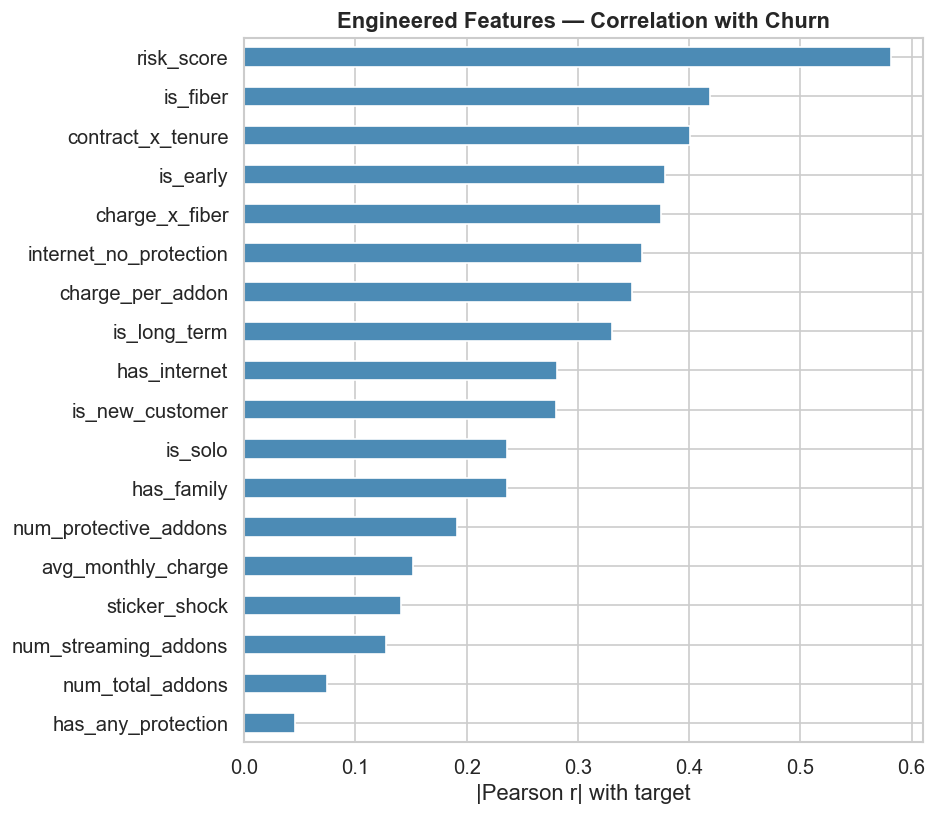

risk_score                0.5811
is_fiber                  0.4188
contract_x_tenure         0.4009
is_early                  0.3783
charge_x_fiber            0.3749
internet_no_protection    0.3576
charge_per_addon          0.3489
is_long_term              0.3307
has_internet              0.2813
is_new_customer           0.2802
is_solo                   0.2361
has_family                0.2361
num_protective_addons     0.1915
avg_monthly_charge        0.1517
sticker_shock             0.1409
num_streaming_addons      0.1274
num_total_addons          0.0741
has_any_protection        0.0458


In [12]:
# ── Quick correlation check: engineered features vs target ────────────────
engineered = [
    'has_internet', 'is_fiber', 'num_protective_addons', 'has_any_protection',
    'internet_no_protection', 'num_streaming_addons', 'num_total_addons',
    'is_new_customer', 'is_early', 'is_long_term', 'contract_x_tenure',
    'avg_monthly_charge', 'charge_per_addon', 'sticker_shock', 'charge_x_fiber',
    'is_solo', 'has_family', 'risk_score'
]

corr = X_train[engineered].corrwith(y_train).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
corr.plot.barh(ax=ax, color='#4C8BB5', edgecolor='white')
ax.set_title('Engineered Features — Correlation with Churn', fontweight='bold')
ax.set_xlabel('|Pearson r| with target')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(corr.round(4).to_string())

---
## 7. Save to Disk

In [13]:
import os

OUT_DIR = DATA_DIR + "processed/"
os.makedirs(OUT_DIR, exist_ok=True)

X_train.to_csv(OUT_DIR + "X_train.csv", index=False)
y_train.to_csv(OUT_DIR + "y_train.csv", index=False)
X_test.to_csv( OUT_DIR + "X_test.csv",  index=False)

# Also save IDs for submission file
test_raw[['id']].to_csv(OUT_DIR + "test_ids.csv", index=False)

print(f"Saved to {OUT_DIR}")
print(f"  X_train.csv : {X_train.shape}")
print(f"  y_train.csv : {y_train.shape}")
print(f"  X_test.csv  : {X_test.shape}")
print(f"  test_ids.csv: {test_raw.shape[0]:,} rows")
print()
print("Ready for modelling notebook.")

Saved to /Users/clairedebadts/kaggle/customer-churn/data/processed/
  X_train.csv : (594194, 41)
  y_train.csv : (594194,)
  X_test.csv  : (254655, 41)
  test_ids.csv: 254,655 rows

Ready for modelling notebook.
